<a href="https://colab.research.google.com/github/paulnord/ExampleCode/blob/main/General_Fitting_Using_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/paulnord/ExampleCode/blob/main/Toy_LSTM_fitting_periodic_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fitting Using Python

#### Always use File/Make a Copy... to create a copy of this template before using it.
This notebook can be modified to fit and plot any function you want.
<br>To run the code in each cell, press shift+enter.

In [ ]:
#Need these library functions. Press shift-enter to run this code.
import pandas as pd   #get the Pandas library to use its functions
import numpy as np    #get the numerical library (numpy) to work with data
from scipy.optimize import curve_fit  #Fitting
from scipy import stats  #For evaluating the fit.
import matplotlib.pyplot as plt  #plotting library
%matplotlib inline

In [ ]:
#Read in your data.
#If your data is in Excel, use this code
#Place your data folder in the same directory as this code.
df = pd.read_excel("Bev_6_1_datafile.xlsx")
data = np.asarray(df)
x = data[:,0]
y = data[:,1]

#It's best if your y-values have errors. Figure some out and put them in a third column in the spreadsheet.
yerr = data[:,2]

#If you can't do that for some reason, you can give all the y-values the same error.
#Put a # in front of yerr above and remove the # from the guess and yerr lines below
#Then change guess to the value you are guessings as the error in y.

#guess = 1
#yerr = np.ones(len(y))*guess

In [ ]:
#If your data is just a .txt or .csv file with numbers and no headers, use this instead.
#Again, you should have something for the y-errors in the third column.
#Remove the # in front of the next line if you want to use this method

#x, y, yerr = np.loadtxt('Text datafile.txt', unpack=True)

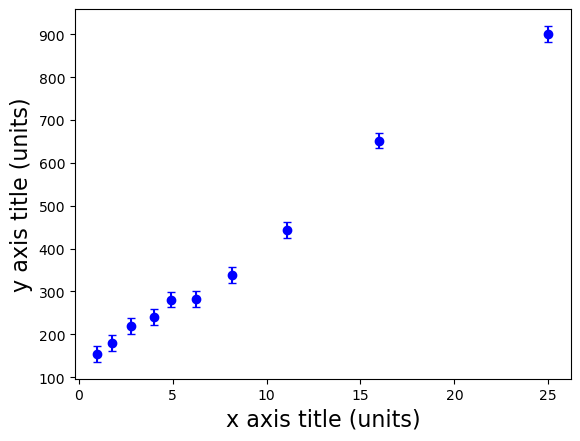

In [ ]:
#Plot the data
fig = plt.figure()
ax = plt.axes()
#ax.set_xscale("log")   #Remove front # to make x-axis log scale
#ax.set_yscale("log")   #Remove front # to make y-axis log scale
ax.errorbar(x , y, yerr=yerr, fmt = 'bo', capsize = 3)  #if you don't want errorbars, remove "yerr=yerr"
plt.xlabel('x axis title (units)',fontsize = 16)  #change the text to the correct title and units
plt.ylabel('y axis title (units)',fontsize = 16)  #change the text to the correct title and units
plt.show()
#plt.savefig('test.png')   #Remove the # to save the image in the current folder for use in a report/paper.
plt.show()

## Curve Fitting
Now that you know what your data looks like, you can create a fit function and make some guesses at parameters of the fit.
The key is changing the fit_function(x,a,b), adjusting the function and the list of parameters of that function (a,b).
In the second block below, you input your guesses for your fit. For all but the simplest of fitting functions, it's important that these are fairly good guesses; otherwise, you can end up with nonsense for your fit.

In [ ]:
#Change the y = line to the fit function you want.
#Include the fit parameters (e.g., a, b) after x. Your parameters may be different in name and number
#Create a new fit_function to define your own, or uncomment out one of the functions below to use that particular function.

#Example: a linear function
def fit_function(x,a,b):
    y = a + b*x
    return y

#Example: a Gaussian peak with amplitude a, position b, and width c.
#def fit_function(x,a,b,c):
#    y = a*np.exp(-(x-b)**2/(2*c**2))
#    return y

#Example: a polynomial fit with parameters a, b, and c.
#def fit_function(x,a,b,c):
#    y = a*x**2 + b*x + c
#    return y


In [ ]:
#Make some reasonable guess about what the fit parameters should be.
#Enter the numbers into the p0 list in the same order that they show up in the fit function.
#For example, here I'm setting a = 1, and b = 2 as my initial guesses.
p0 = [10,30]

#Then call the curve_fit() routine. It needs the fitting function, x values, y values, guess for parameters, and the errors.
params, pcov = curve_fit(fit_function, x, y, p0, sigma = yerr)
perrs = np.sqrt(np.diag(pcov))

#print out the parameters in the same order as in the function definition
print('Fitted parameters')
print(params)
print()
#print out the errors in the parameters, in the same order as in the function definition.
print('Errors in parameters')
print(perrs)
print()
print('Covariance matrix')
print(pcov)
#create a fit curve from these fitted parameters.
fit_curve = fit_function(x, *params)

Fitted parameters
[114.2810614   31.47674561]

Errors in parameters
[10.78733405  1.00053516]

Covariance matrix
[[116.36657589  -8.11049427]
 [ -8.11049427   1.00107061]]


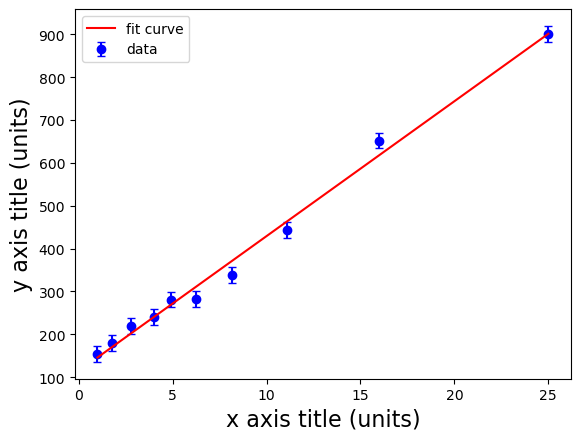

In [ ]:
#Plot the data and the fit curve
fig = plt.figure()
ax = plt.axes()
#ax.set_xscale("log")   #Remove front # to make x-axis log scale
#ax.set_yscale("log")   #Remove front # to make y-axis log scale
ax.errorbar(x,y, yerr=yerr, fmt = 'bo',capsize = 3, label = 'data')  #if you don't want errorbars, remove "yerr=yerr"
ax.plot(x,fit_curve,'r-', label = "fit curve", zorder = 10)  #plot the fit curve
plt.xlabel('x axis title (units)',fontsize = 16)  #change the text to the correct title and units
plt.ylabel('y axis title (units)',fontsize = 16)  #change the text to the correct title and units
plt.legend()
plt.show()
#plt.savefig('test.png')   #Remove the # to save the image in the current folder for use in a report/paper.
plt.show()

In [ ]:
#Here I define a function to calculate the reduced chi^2 and the residuals
#Don't change this function.
def reduced_chisquare(observed_values,expected_values,yerr, params):
    '''Calculates the reduced chi-squared by calculating the residuals (difference/error)
    for each point, then summing their squares, then dividing by the degrees of freedom.
    Returns the reduced chi-squared and a list of the residuals'''
    chi2=0
    residuals = []
    for observed, expected, ye in zip(observed_values, expected_values, yerr):
        residuals.append((observed-expected)/abs(ye))
        chi2+=(residuals[-1])**2
    return chi2/(len(observed_values)-len(params)), residuals

In [ ]:
#Don't change the code in this cell. Just run it.
chi2, residuals = reduced_chisquare(y,fit_curve,yerr,params)
#print out the chi^2 value. Ideally, this should be close to 1 (e.g. between ~0.8 and ~1.3)
print(f'The reduced chi^2 of the fit is {chi2:0.2f}')

The reduced chi^2 of the fit is 1.48


In [ ]:
# Calculate the p-value using the survival function (1 - CDF)
import scipy.stats as stats

chi_square_statistic = 7  # Example chi-square statistic--note this is chi-square, not reduced chi-square
degrees_of_freedom = len(y)-len(params)    # Example degrees of freedom (df)

stats.chi2.sf(chi_square_statistic, degrees_of_freedom)
p_value = stats.chi2.sf(chi_square_statistic, degrees_of_freedom)
print(f"degrees of freedom: {degrees_of_freedom}")
print(f"reduced chi^2: {chi2}")
print(f"P-value: {p_value}")

degrees of freedom: 8
reduced chi^2: 1.4801112853676583
P-value: 0.536632667900785


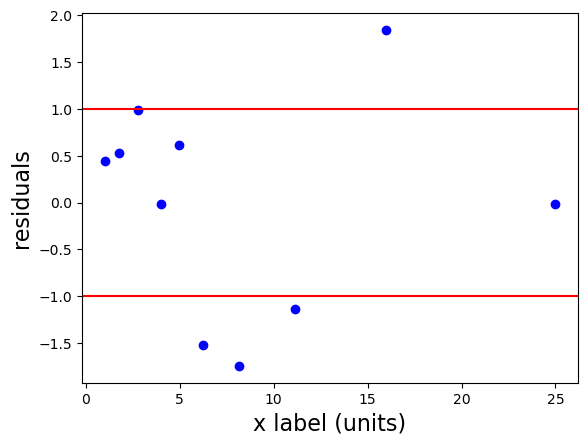

In [ ]:
#Plot the residuals. If chi2 is around 1, we should expect ~2/3 the residuals to be within +/- 1.
#And you should see no "structure" in this plot (it should look bascially random)
#Don't change any of this code.
plt.plot(x,residuals,'bo',label='residuals')
plt.xlabel('x label (units)',fontsize = 16); plt.ylabel('residuals', fontsize = 16)
plt.axhline(y=1,color='r')   #Add some lines to indicate the +/-1 sigma level
plt.axhline(y=-1,color='r')
#plt.savefig('Residuals plot.png')  #remove # at the front to save this residuals plot.
plt.show()

In [ ]:
#If the fit is linear, calculate the Pearson R^2 value.
#If it isn't linear, this number means nothing and it should be ignored.
#If it is linear, then the closer this number is to 1.0, the more correlated the x and y values are.
cov = np.cov(x,y)
r = cov[0,1]/np.sqrt(cov[0,0]*cov[1,1])
print(f'The R^2 value is {r**2:0.4f}')

The R^2 value is 0.9920


Use this box to give your final results and to discuss the fit (replace this text).
